In [1]:
import os
from PIL import Image

IMG_DIR = r"E:\CliniScan\B13-CliniScan\data\kaggle\working\preprocessed_jpg_5000"

files = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")]
print("Total images found:", len(files))

sizes = set()
for f in files[:50]:
    img = Image.open(os.path.join(IMG_DIR, f))
    sizes.add(img.size)

print("Unique image sizes found:", sizes)

Total images found: 5000
Unique image sizes found: {(224, 224)}


In [1]:
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import pydicom
import torch
import albumentations
import matplotlib
import seaborn
import tqdm
import yaml

print("✅ All libraries imported successfully!")

c:\Users\vishn\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!


In [2]:
import os
import pandas as pd

IMG_DIR = r"E:\CliniScan\B13-CliniScan\data\kaggle\working\preprocessed_jpg_5000"
LABELS_CSV = r"E:\CliniScan\B13-CliniScan\data\labels_5000.csv"

# Load labels
df = pd.read_csv(LABELS_CSV)

image_files = set(os.listdir(IMG_DIR))
label_files = set(df["image_id"].values)

print("Images in folder:", len(image_files))
print("Images in labels CSV:", len(label_files))

missing_in_labels = image_files - label_files
missing_in_folder = label_files - image_files

print("Missing in labels:", len(missing_in_labels))
print("Missing in folder:", len(missing_in_folder))

Images in folder: 5000
Images in labels CSV: 5000
Missing in labels: 0
Missing in folder: 0


In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd

LABELS_CSV = r"E:\CliniScan\B13-CliniScan\data\labels_5000.csv"

df = pd.read_csv(LABELS_CSV)

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# Save splits
train_df.to_csv(r"E:\CliniScan\B13-CliniScan\data\train_labels.csv", index=False)
val_df.to_csv(r"E:\CliniScan\B13-CliniScan\data\val_labels.csv", index=False)
test_df.to_csv(r"E:\CliniScan\B13-CliniScan\data\test_labels.csv", index=False)

Train: 3500
Validation: 750
Test: 750


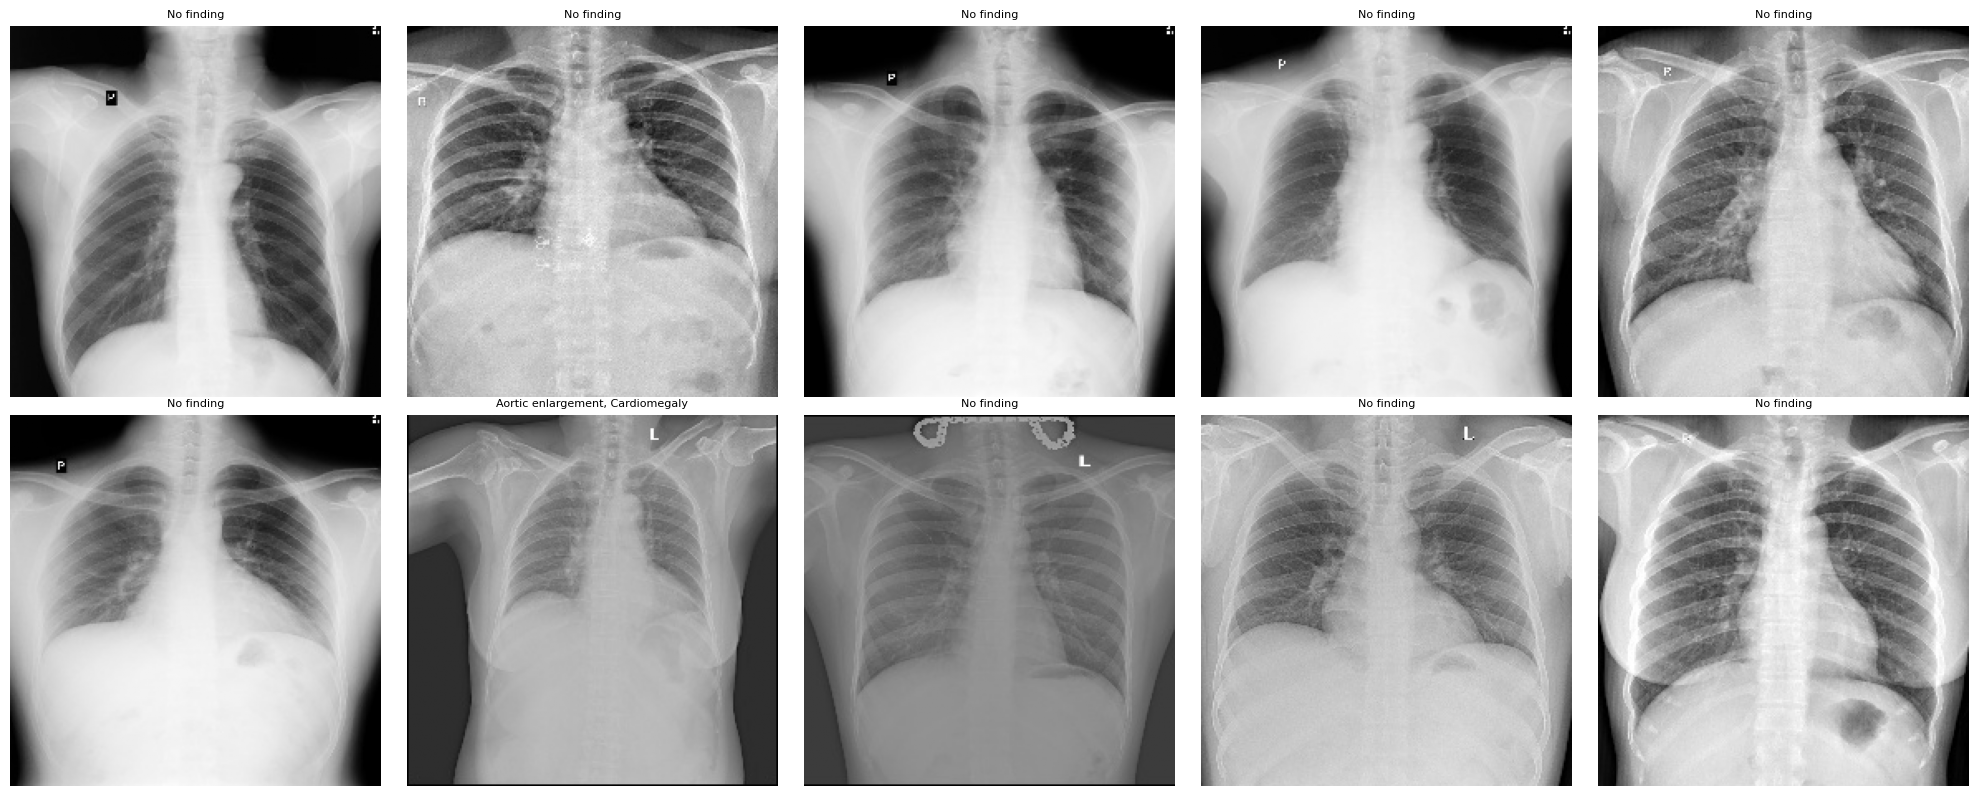

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import pandas as pd

IMG_DIR = r"E:\CliniScan\B13-CliniScan\data\kaggle\working\preprocessed_jpg_5000"
train_df = pd.read_csv(r"E:\CliniScan\B13-CliniScan\data\train_labels.csv")

samples = train_df.sample(10)

plt.figure(figsize=(20, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img_path = os.path.join(IMG_DIR, row["image_id"])
    img = Image.open(img_path)

    labels = row.drop("image_id")
    positive = labels[labels == 1].index.tolist()

    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(", ".join(positive) if positive else "No finding", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()